In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sn
import yfinance as yf
from datetime import datetime
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, RepeatVector, TimeDistributed
from keras.optimizers import Adam
import seaborn as sns
from scipy.optimize import minimize
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler

In [2]:
selected_tickers = ['NOW', 'IBM', 'BABA', 'NFLX', 'CSCO', 'META', 'ADBE', '0700.HK', 'ACN', 'AAPL']


start_date = '2020-01-01'


end_date = datetime.now().strftime('%Y-%m-%d')


stock_data = {}
for symbol in selected_tickers:
    try:
        stock_data[symbol] = yf.download(symbol, start=start_date, end=end_date)
        print(f"Data successfully retrieved for {symbol}.")
    except Exception as e:
        print(f"Error fetching data for {symbol}: {e}")

for symbol, data in stock_data.items():
    print(f"Stock Symbol: {symbol}")
    print(data.tail(2))
    print()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Data successfully retrieved for NOW.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Data successfully retrieved for IBM.
Data successfully retrieved for BABA.


...

Data successfully retrieved for 0700.HK.


[*********************100%***********************]  1 of 1 completed


Data successfully retrieved for ACN.


[*********************100%***********************]  1 of 1 completed

Data successfully retrieved for AAPL.
Stock Symbol: NOW
Price            Close        High         Low        Open   Volume
Ticker             NOW         NOW         NOW         NOW      NOW
Date                                                               
2025-04-28  937.409973  961.030029  927.130005  959.849976  2052400
2025-04-29  942.859985  947.229980  930.549988  940.000000  1245300

Stock Symbol: IBM
Price            Close        High         Low        Open   Volume
Ticker             IBM         IBM         IBM         IBM      IBM
Date                                                               
2025-04-28  236.160004  236.630005  232.070007  232.860001  3653500
2025-04-29  239.389999  239.979996  236.139999  237.000000  3424700

Stock Symbol: BABA
Price            Close        High         Low        Open    Volume
Ticker            BABA        BABA        BABA        BABA      BABA
Date                                                                
2025-04-28  118.37

In [3]:
close_prices = pd.concat([data['Close'] for data in stock_data.values()], axis=1)
close_prices.columns = selected_tickers

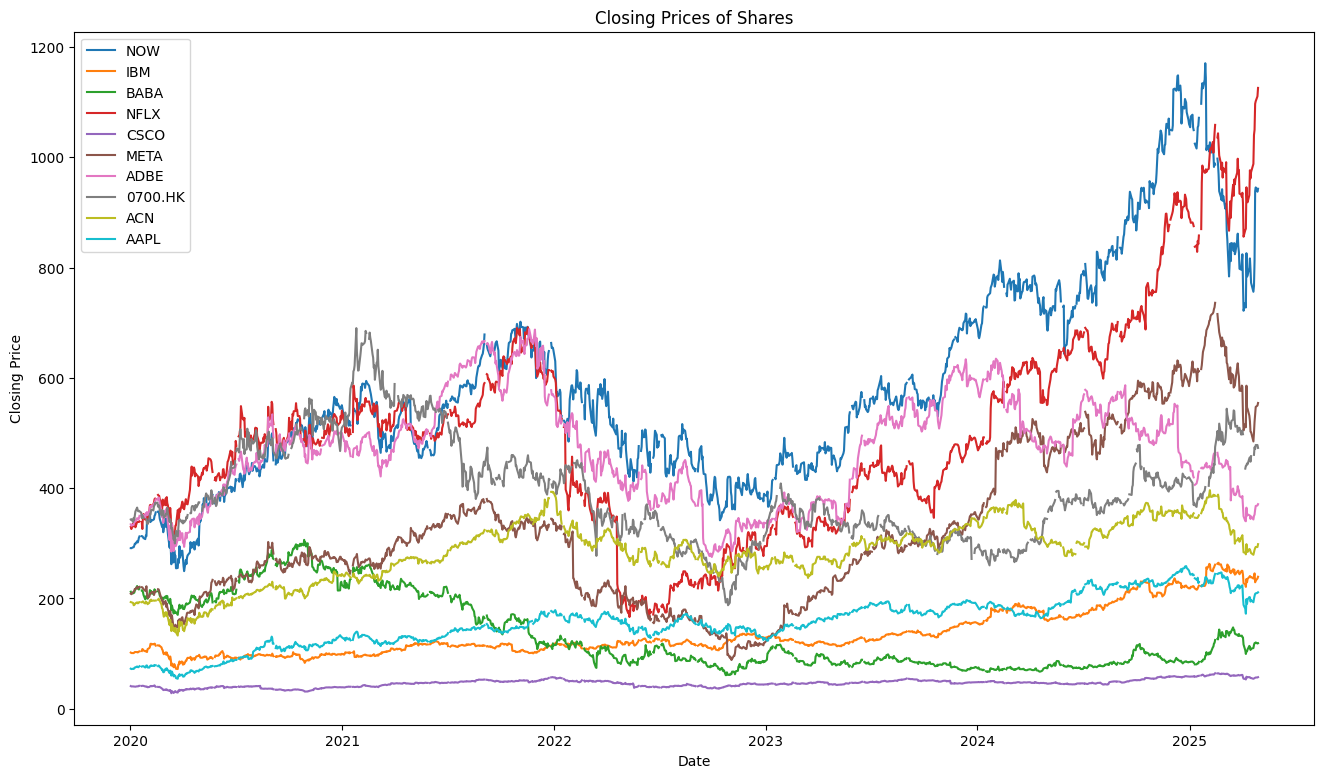

In [4]:
plt.figure(figsize=(16, 9))
for column in close_prices.columns:
    plt.plot(close_prices.index, close_prices[column], label=column)
plt.title("Closing Prices of Shares")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

<ipython-input-5-90710b86b783>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_tickers, y=weights.flatten(), palette="Blues_d")


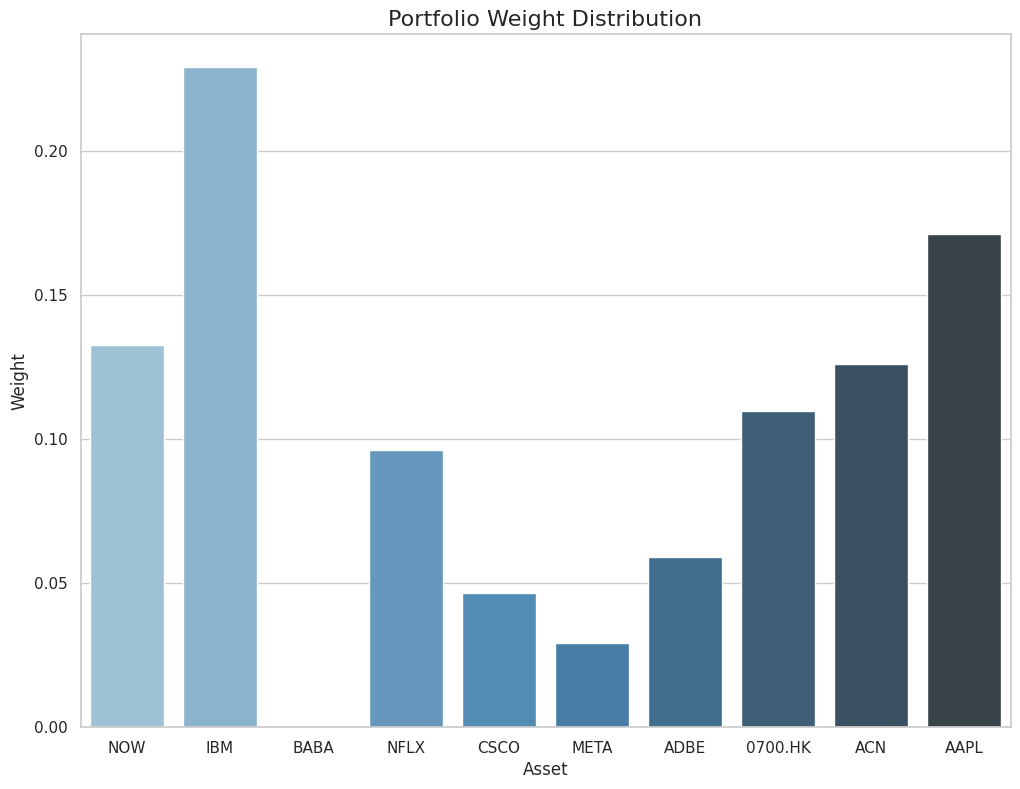


Expected return of the portfolio is : 11.954486607270045

Volatility of the portfolio: 0.2019255399137122

Sharpe ratio of the portfolio: 0.5920244963751734


In [5]:
np.random.seed(1)
weights = np.random.random((10, 1))
weights /= np.sum(weights)

sns.set(style="whitegrid")
plt.figure(figsize=(12, 9))
sns.barplot(x=selected_tickers, y=weights.flatten(), palette="Blues_d")
plt.title('Portfolio Weight Distribution', fontsize=16)
plt.ylabel('Weight', fontsize=12)
plt.xlabel('Asset', fontsize=12)
plt.show()

log_ret = np.log(close_prices / close_prices.shift(1))
log_ret

exp_ret = log_ret.mean().dot(weights)*182
print(f'\nExpected return of the portfolio is : {exp_ret[0]*100}')


exp_vol = np.sqrt(weights.T.dot(182*log_ret.cov().dot(weights)))
print(f'\nVolatility of the portfolio: {exp_vol[0][0]}')

# Sharpe ratio
sr = exp_ret / exp_vol
print(f'\nSharpe ratio of the portfolio: {sr[0][0]}')

In [6]:
n = 50_000

port_weights = np.zeros(shape=(n,len(close_prices.columns)))
port_volatility = np.zeros(n)
port_sr = np.zeros(n)
port_return = np.zeros(n)

num_securities = len(close_prices.columns)

for i in range(n):
    # Weight each security
    weights = np.random.random(10)
    # normalize it, so that some is one
    weights /= np.sum(weights)
    port_weights[i,:] = weights

    #ho utilizzato la lunghezza del test size
    exp_ret = log_ret.mean().dot(weights)*182
    port_return[i] = exp_ret

    # Exp Volatility (Risk)
    exp_vol = np.sqrt(weights.T.dot(182*log_ret.cov().dot(weights)))
    port_volatility[i] = exp_vol

    # Sharpe ratio
    sr = exp_ret / exp_vol
    port_sr[i] = sr

In [8]:

max_sr = port_sr.max()
ind = port_sr.argmax()
# Return and Volatility at Max SR
max_sr_ret = port_return[ind]
max_sr_vol = port_volatility[ind]

In [10]:
max_sr_ret/max_sr_vol

np.float64(0.6357362345698906)

6.54 % of NOW should be bought.
33.64 % of IBM should be bought.
2.05 % of BABA should be bought.
26.87 % of NFLX should be bought.
15.37 % of CSCO should be bought.
1.58 % of META should be bought.
1.68 % of ADBE should be bought.
1.04 % of 0700.HK should be bought.
2.01 % of ACN should be bought.
9.21 % of AAPL should be bought.


<ipython-input-11-eed8cfd177bd>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_tickers, y=port_weights[ind], palette="Blues_d")


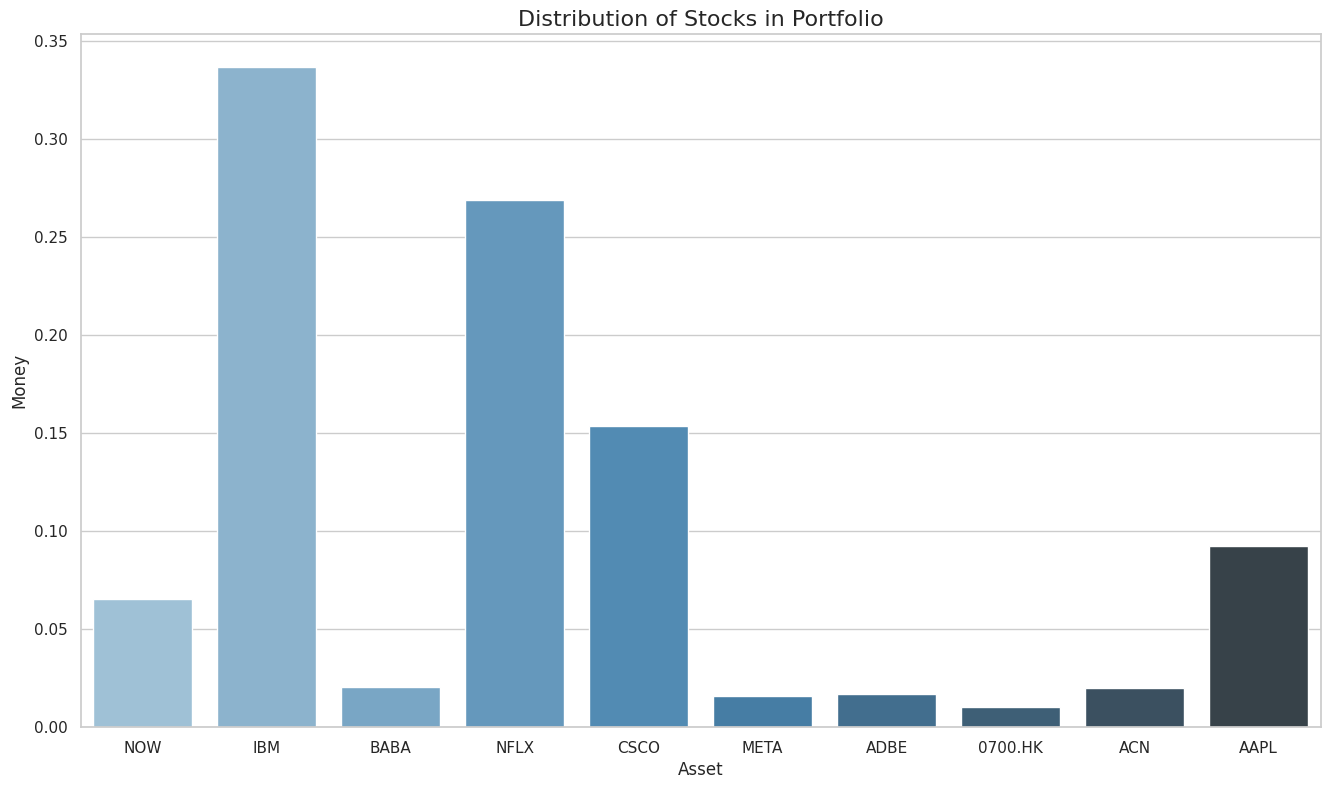


Markowitz optimal portfolio return is : 13.37% with volatility 0.21033217982260868


In [11]:
for weight, stock in zip(port_weights[ind],close_prices):
    print(f'{round(weight * 100, 2)} % of {stock} should be bought.')

sns.set(style="whitegrid")
plt.figure(figsize=(16, 9))
sns.barplot(x=selected_tickers, y=port_weights[ind], palette="Blues_d")
plt.title('Distribution of Stocks in Portfolio', fontsize=16)
plt.ylabel('Money', fontsize=12)
plt.xlabel('Asset', fontsize=12)
plt.show()

# best portfolio return
print(f'\nMarkowitz optimal portfolio return is : {round(max_sr_ret * 100, 2)}% with volatility \
{max_sr_vol}')


CALCULATE LOG_RETURN

In [12]:
log_ret= log_ret[1:].dropna()


LSTM

In [13]:
train, test = log_ret[:int(0.8*len(log_ret))], log_ret[int(0.8*len(log_ret)):]

In [14]:
train.shape, test.shape

((948, 10), (237, 10))

In [15]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

In [16]:
# functions for training and evaluation - training DL.ipynb
# alternative to keras' TimeSeriesGenerator
def split_sequence(sequence, look_back, forecast_horizon):
    X, y = list(), list()
    for i in range(len(sequence)):
        lag_end = i + look_back
        forecast_end = lag_end + forecast_horizon
        if forecast_end > len(sequence):
            break
        seq_x, seq_y = sequence[i:lag_end], sequence[lag_end:forecast_end]
        X.append(seq_x)
        y.append(seq_y)
    return np.array(X), np.array(y)

In [17]:
FORECAST_RANGE =1
LOOK_BACK = 30

In [18]:
X_train, y_train = split_sequence(scaled_train, look_back=LOOK_BACK, forecast_horizon=FORECAST_RANGE)
X_test, y_test = split_sequence(scaled_test, look_back=LOOK_BACK, forecast_horizon=FORECAST_RANGE)
print('(Samples, time steps, features)')
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(Samples, time steps, features)
(918, 30, 10)
(918, 1, 10)
(207, 30, 10)
(207, 1, 10)


In [19]:
lstm = Sequential(name='LSTM')
lstm.add(LSTM(100, activation='relu', input_shape=(LOOK_BACK, 10)))
lstm.add(RepeatVector(FORECAST_RANGE))
lstm.add(LSTM(100, activation='relu', return_sequences=True))
lstm.add(TimeDistributed(Dense(10)))
lstm.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        44,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 1, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 100)         │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 1, 10)          │         1,010 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,810 (491.45 KB)

 Trainable params: 125,810 (491.45 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:

lstm.compile(optimizer='adam', loss='mse')

In [21]:
history = lstm.fit(X_train, y_train, epochs=30, batch_size=32)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.2348
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0999
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0074
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0066
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0061
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0064
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0063
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0066
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0069
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0072
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0066
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0063
Epoch 13/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0069
Epoch 14/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0061
Epoch 15/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0061
Epoc

In [22]:
predicted_returns = lstm.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


In [23]:
predicted_returns.shape

(207, 1, 10)

optimal weigths: [1.37141932e-19 3.46301465e-01 0.00000000e+00 9.28006070e-02
 2.18121170e-01 0.00000000e+00 0.00000000e+00 2.19841501e-01
 7.83269517e-02 4.46083046e-02]


<ipython-input-24-4fa9b4717526>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_tickers, y=optimal_weights, palette="Blues_d")


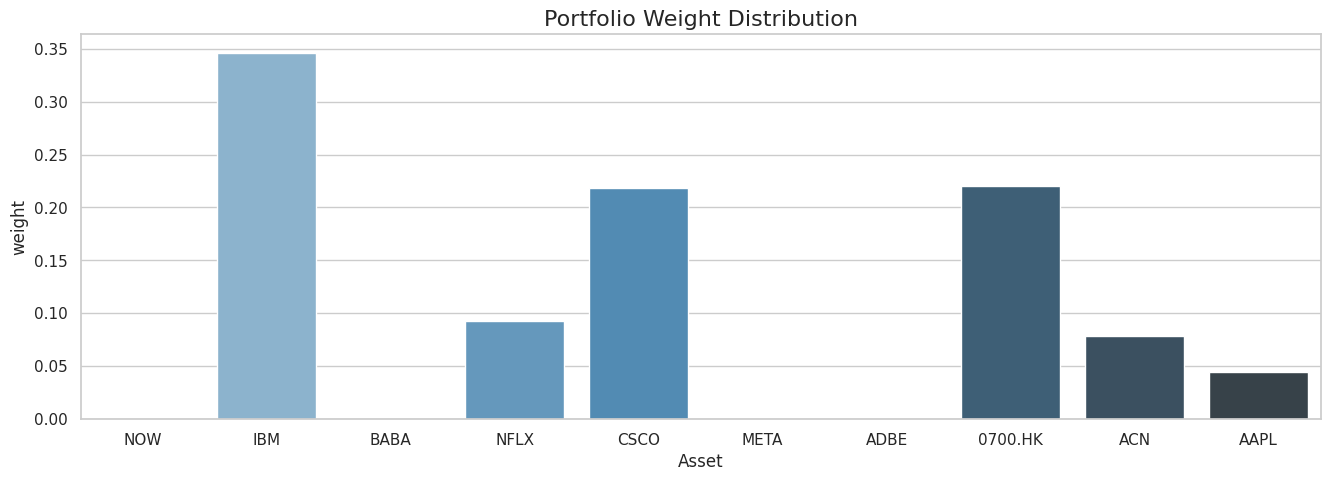

In [24]:

def portfolio_performance(weights, expected_returns, covariance_matrix):
    portfolio_return = np.dot(weights, expected_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix, weights)))
    return portfolio_return, portfolio_risk


def minimize_risk(weights):
    weights = np.array(weights)
    return portfolio_performance(weights, np.mean(predicted_returns, axis=0).flatten(), log_ret.cov())[1]

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(len(selected_tickers)))


initial_weights = [1. / len(selected_tickers)] * len(selected_tickers)
optimal = minimize(minimize_risk, initial_weights, method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = optimal.x
print("optimal weigths:", optimal_weights)
sns.set(style="whitegrid")
plt.figure(figsize=(16, 5))
sns.barplot(x=selected_tickers, y=optimal_weights, palette="Blues_d")
plt.title('Portfolio Weight Distribution', fontsize=16)
plt.ylabel('weight', fontsize=12)
plt.xlabel('Asset', fontsize=12)
plt.show()



In [25]:
optimal_return, optimal_risk = portfolio_performance(optimal_weights, np.mean(predicted_returns, axis=0).flatten(), log_ret.cov())
print(f"Expected Portfolio Return': {optimal_return*100}")
print(f"Portfolio Risk: {optimal_risk*100}")



Expected Portfolio Return': 52.087590420849196
Portfolio Risk: 1.3250663388068276
